In [ ]:
#importing the libraries reqquired
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Define the ticker symbol i.e. EUR/INR currency data
ticker_code = 'EURINR=X'

# Scraping data on this ticker from Yahoo Finance
ticker_data = yf.Ticker(ticker_code)

# Get the historical prices for EUR/INR covering the period from January 1, 2023, to sept 30, 2024.
#creating a varaible EI_CD:EUR/INR currency data
EI_CD = ticker_data.history(period='1d', start='2023-01-01', end='2024-10-01') # to get the 30th date end date is added with +1

In [ ]:
## Displaying the dataframe
EI_CD

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-01-02 00:00:00+00:00,87.157700,88.400002,87.157700,88.482002,0,0.0,0.0
2023-01-03 00:00:00+00:00,88.292000,88.313004,87.225998,88.300003,0,0.0,0.0
2023-01-04 00:00:00+00:00,87.219002,87.922997,87.219002,87.219002,0,0.0,0.0
2023-01-05 00:00:00+00:00,87.580002,87.807999,86.757004,87.605003,0,0.0,0.0
2023-01-06 00:00:00+00:00,86.819000,87.614998,86.647003,86.827003,0,0.0,0.0
...,...,...,...,...,...,...,...
2024-09-24 00:00:00+01:00,92.775002,93.248001,92.671997,92.753998,0,0.0,0.0
2024-09-25 00:00:00+01:00,93.490997,93.627998,93.083000,93.438004,0,0.0,0.0
2024-09-26 00:00:00+01:00,92.995003,93.467003,92.994003,93.000999,0,0.0,0.0


In [ ]:
#Print the shape of Dataframe and checking null values (if any)
print("The EUR/INR dataset has "+ '\033[1m'+ f"{EI_CD.shape[0]}"+'\033[0m'+' rows and '+ '\033[1m'+
      f"{EI_CD.shape[1]}"+'\033[0m' + ' columns')
print("The EUR/INR dataset " + f"{'has no' if EI_CD.isnull().values.any()==0 else 'has'} null values")

The EUR/INR dataset has 456 rows and 7 columns
The EUR/INR dataset has no null values


In [ ]:
#Undertanding the data getting info about the columns
EI_CD.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 456 entries, 2023-01-02 00:00:00+00:00 to 2024-09-30 00:00:00+01:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          456 non-null    float64
 1   High          456 non-null    float64
 2   Low           456 non-null    float64
 3   Close         456 non-null    float64
 4   Volume        456 non-null    int64  
 5   Dividends     456 non-null    float64
 6   Stock Splits  456 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 28.5 KB


In [ ]:
#Technical Analysis (TA)
#TA1: Moving Average (MA)
#MA type: Simple moving avergae (SMA)
EI_CD['MA_10'] = EI_CD['Close'].rolling(window=10).mean() # 10 days SMA
EI_CD['MA_50'] = EI_CD['Close'].rolling(window=50).mean() # 50 days SMA

In [ ]:
#Checking the Dataframe after TA1
print(EI_CD)

                                Open       High        Low      Close  Volume  \
Date                                                                            
2023-01-02 00:00:00+00:00  87.157700  88.400002  87.157700  88.482002       0   
2023-01-03 00:00:00+00:00  88.292000  88.313004  87.225998  88.300003       0   
2023-01-04 00:00:00+00:00  87.219002  87.922997  87.219002  87.219002       0   
2023-01-05 00:00:00+00:00  87.580002  87.807999  86.757004  87.605003       0   
2023-01-06 00:00:00+00:00  86.819000  87.614998  86.647003  86.827003       0   
...                              ...        ...        ...        ...     ...   
2024-09-24 00:00:00+01:00  92.775002  93.248001  92.671997  92.753998       0   
2024-09-25 00:00:00+01:00  93.490997  93.627998  93.083000  93.438004       0   
2024-09-26 00:00:00+01:00  92.995003  93.467003  92.994003  93.000999       0   
2024-09-27 00:00:00+01:00  93.371002  93.629997  93.037003  93.367996       0   
2024-09-30 00:00:00+01:00  9

In [ ]:
#TA2: Bollinger Band
EI_CD['MA_20'] = EI_CD['Close'].rolling(window=20).mean() # 20 days SMA

# Calculating the standard deviation of 20 days SMA
EI_CD['std_dev'] = EI_CD['Close'].rolling(window=20).std()

# Calculating the upper and lower Bollinger Bands
EI_CD['Upper'] = EI_CD['MA_20'] + 2 * EI_CD['std_dev']
EI_CD['Lower'] = EI_CD['MA_20'] - 2 * EI_CD['std_dev']

In [ ]:
#TA3: CCI
#TP: Typical Price calculation
TP = (EI_CD['High'] + EI_CD['Low'] + EI_CD['Close']) / 3

#CCI calculation
CCI = (TP - TP.rolling(20).mean()) / (0.015 * TP.rolling(20).std())
EI_CD['CCI'] = CCI #applying CCI on Dataframe

In [ ]:
#metrics for one day and one week from Sept 30,2024
ODM = EI_CD.loc['2024-09-30'] #one day matrices
OWM = EI_CD.loc['2024-09-24':'2024-09-30'] #one week matrices

In [ ]:
#Displaying one day matrices
print(ODM)

Open            92.414001
High            93.839996
Low             92.414001
Close           93.369003
Volume           0.000000
Dividends        0.000000
Stock Splits     0.000000
MA_10           93.154400
MA_50           92.306294
MA_20           92.933500
std_dev          0.364013
Upper           93.661526
Lower           92.205475
CCI             63.247523
Name: 2024-09-30 00:00:00+01:00, dtype: float64


In [ ]:
#Displaying one week matrices
print(OWM)

                                Open       High        Low      Close  Volume  \
Date                                                                            
2024-09-24 00:00:00+01:00  92.775002  93.248001  92.671997  92.753998       0   
2024-09-25 00:00:00+01:00  93.490997  93.627998  93.083000  93.438004       0   
2024-09-26 00:00:00+01:00  92.995003  93.467003  92.994003  93.000999       0   
2024-09-27 00:00:00+01:00  93.371002  93.629997  93.037003  93.367996       0   
2024-09-30 00:00:00+01:00  92.414001  93.839996  92.414001  93.369003       0   

                           Dividends  Stock Splits      MA_10      MA_50  \
Date                                                                       
2024-09-24 00:00:00+01:00        0.0           0.0  92.820700  92.113302   
2024-09-25 00:00:00+01:00        0.0           0.0  92.917800  92.162082   
2024-09-26 00:00:00+01:00        0.0           0.0  92.977600  92.195082   
2024-09-27 00:00:00+01:00        0.0           0.0  

In [ ]:
#Decision making (BUY/SELL/NEUTRAL) based on MA for the specified time frames (ODM & OWM)
ODM['Moving Average Decision'] = np.where((ODM['Close'] > ODM['MA_10']) & (ODM['Close'] > ODM['MA_50']), "Buy", "Neutral")
ODM['Moving Average Decision'] = np.where((ODM['Close'] < ODM['MA_10']) & (ODM['Close'] < ODM['MA_50']), "Sell", ODM['Moving Average Decision']) # Keep previous decision if not 'Sell'
OWM['Moving Average Decision'] = np.where((OWM['Close'] > OWM['MA_10']) & (OWM['Close'] > OWM['MA_50']), "Buy", "Neutral")
OWM['Moving Average Decision'] = np.where((OWM['Close'] < OWM['MA_10']) & (OWM['Close'] < OWM['MA_50']), "Sell", OWM['Moving Average Decision']) # Keep previous decision if not 'Sell'

In [ ]:
#Decision making (BUY/SELL/NEUTRAL) based on Bollinger Band for the specified time frames (ODM & OWM)
ODM['Bollinger Band Decision'] = np.where(ODM['Close'] < ODM['Lower'], "Buy", "Neutral")
ODM['Bollinger Band Decision'] = np.where(ODM['Close'] > ODM['Upper'], "Sell", ODM['Bollinger Band Decision']) # Keep previous decision if not 'Sell'
OWM['Bollinger Band Decision'] = np.where(OWM['Close'] < OWM['Lower'], "Buy", "Neutral")
OWM['Bollinger Band Decision'] = np.where(OWM['Close'] > OWM['Upper'], "Sell", OWM['Bollinger Band Decision']) # Keep previous decision if not 'Sell'

In [ ]:
#Decision making (BUY/SELL/NEUTRAL) based on CCI for the specified time frames (ODM & OWM)
ODM['CCI Decision'] = np.where(ODM['CCI'] > 100, "Sell", "Neutral")
ODM['CCI Decision'] = np.where(ODM['CCI'] <-100, "Buy", ODM['CCI Decision']) # Keep previous decision if not 'Buy'
OWM['CCI Decision'] = np.where(OWM['CCI'] > 100, "Sell", "Neutral")
OWM['CCI Decision'] = np.where(OWM['CCI'] <-100, "Buy", OWM['CCI Decision']) # Keep previous decision if not 'Buy'

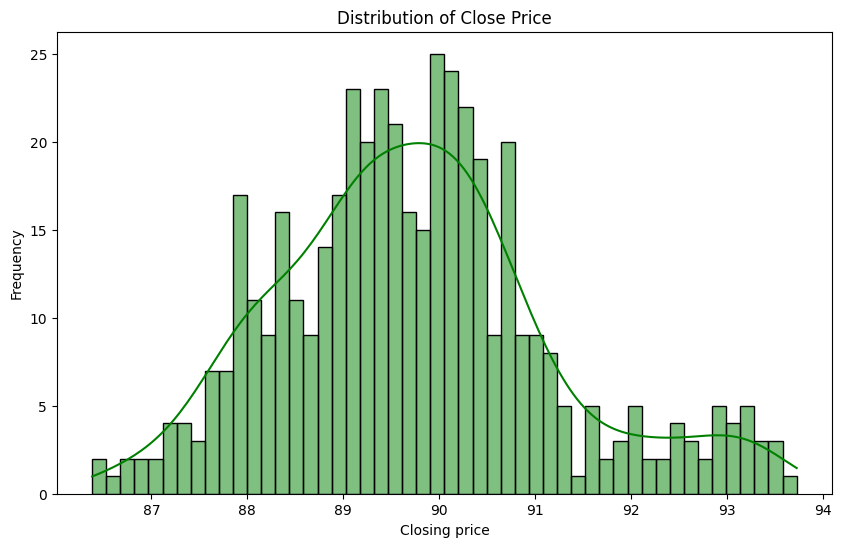

In [ ]:
#graphical representation of distribution of Close Price
plt.figure(figsize=(10, 6))
sns.histplot(data=EI_CD, x='Close', bins=50,color='green', kde=True)
plt.title('Distribution of Close Price')
plt.xlabel('Closing price')
plt.ylabel('Frequency')
plt.show()

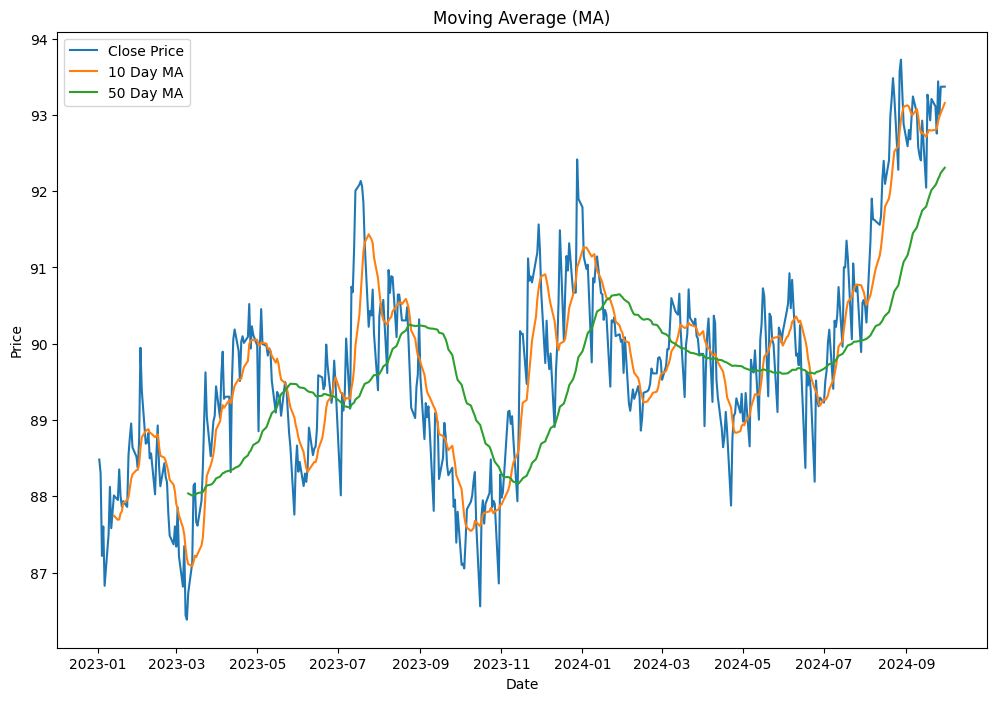

In [ ]:
# Moving Average
plt.figure(figsize=(12, 8))
plt.plot(EI_CD.index, EI_CD['Close'], label='Close Price')
plt.plot(EI_CD.index, EI_CD['MA_10'], label='10 Day MA')
plt.plot(EI_CD.index, EI_CD['MA_50'], label='50 Day MA')
plt.title('Moving Average (MA)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

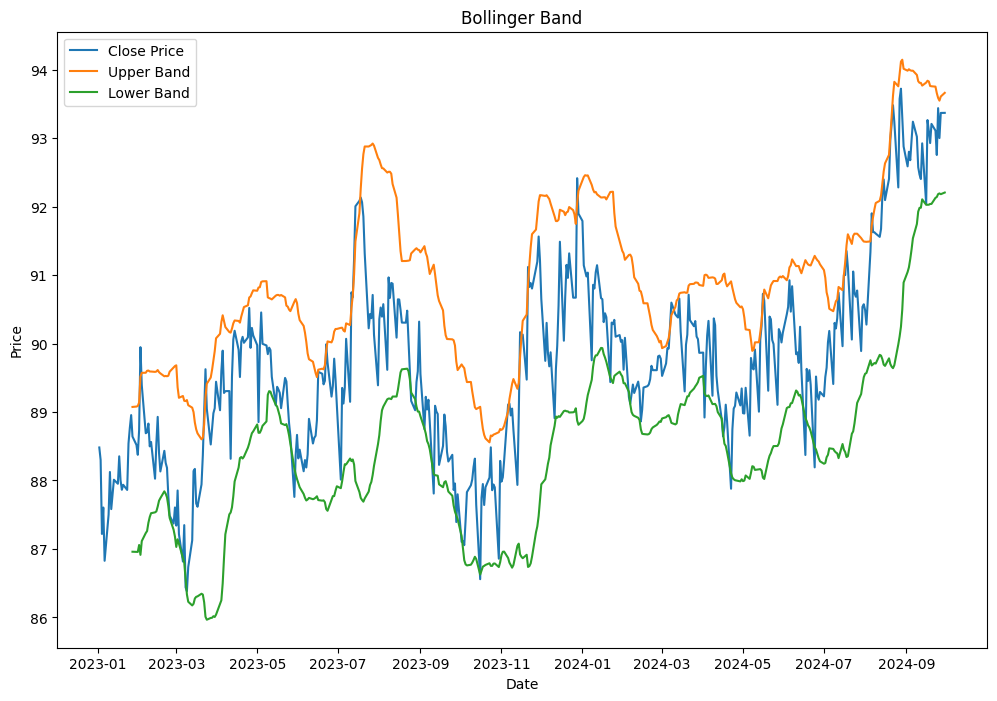

In [ ]:
# Bollinger Band
plt.figure(figsize=(12, 8))
plt.plot(EI_CD.index, EI_CD['Close'], label='Close Price')
plt.plot(EI_CD.index, EI_CD['Upper'], label='Upper Band')
plt.plot(EI_CD.index, EI_CD['Lower'], label='Lower Band')
plt.title('Bollinger Band')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

Text(0, 0.5, 'CCI')

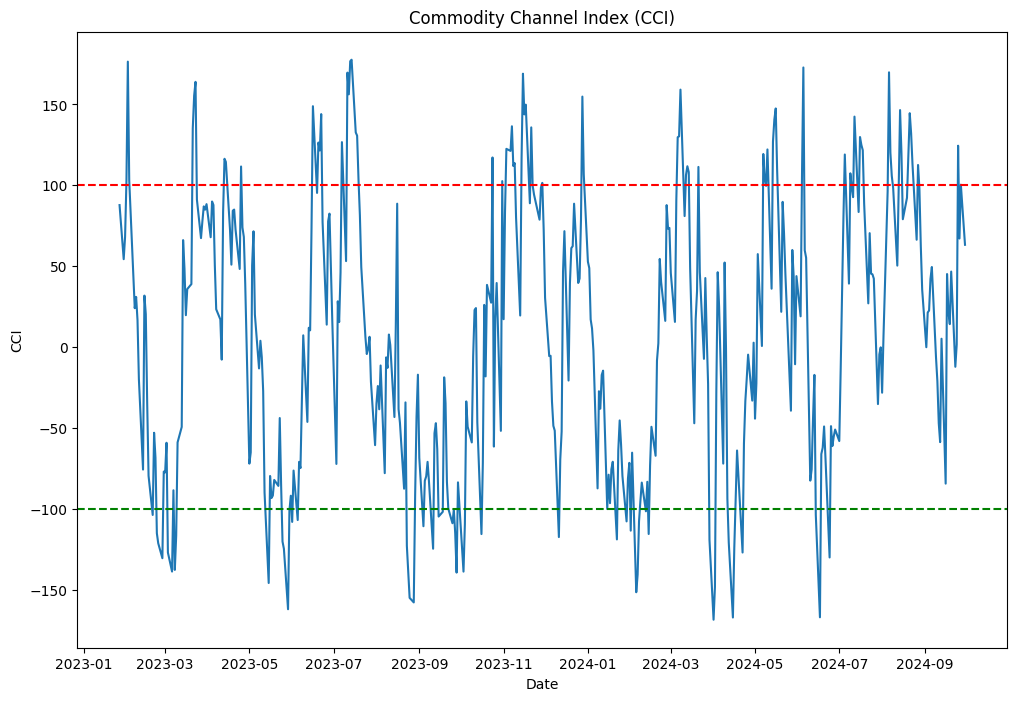

In [ ]:
# CCI
plt.figure(figsize=(12, 8))
plt.plot(EI_CD.index, EI_CD['CCI'], label='CCI')
plt.axhline(y=100, color='r', linestyle='--')
plt.axhline(y=-100, color='g', linestyle='--')
plt.title('Commodity Channel Index (CCI)')
plt.xlabel('Date')
plt.ylabel('CCI')

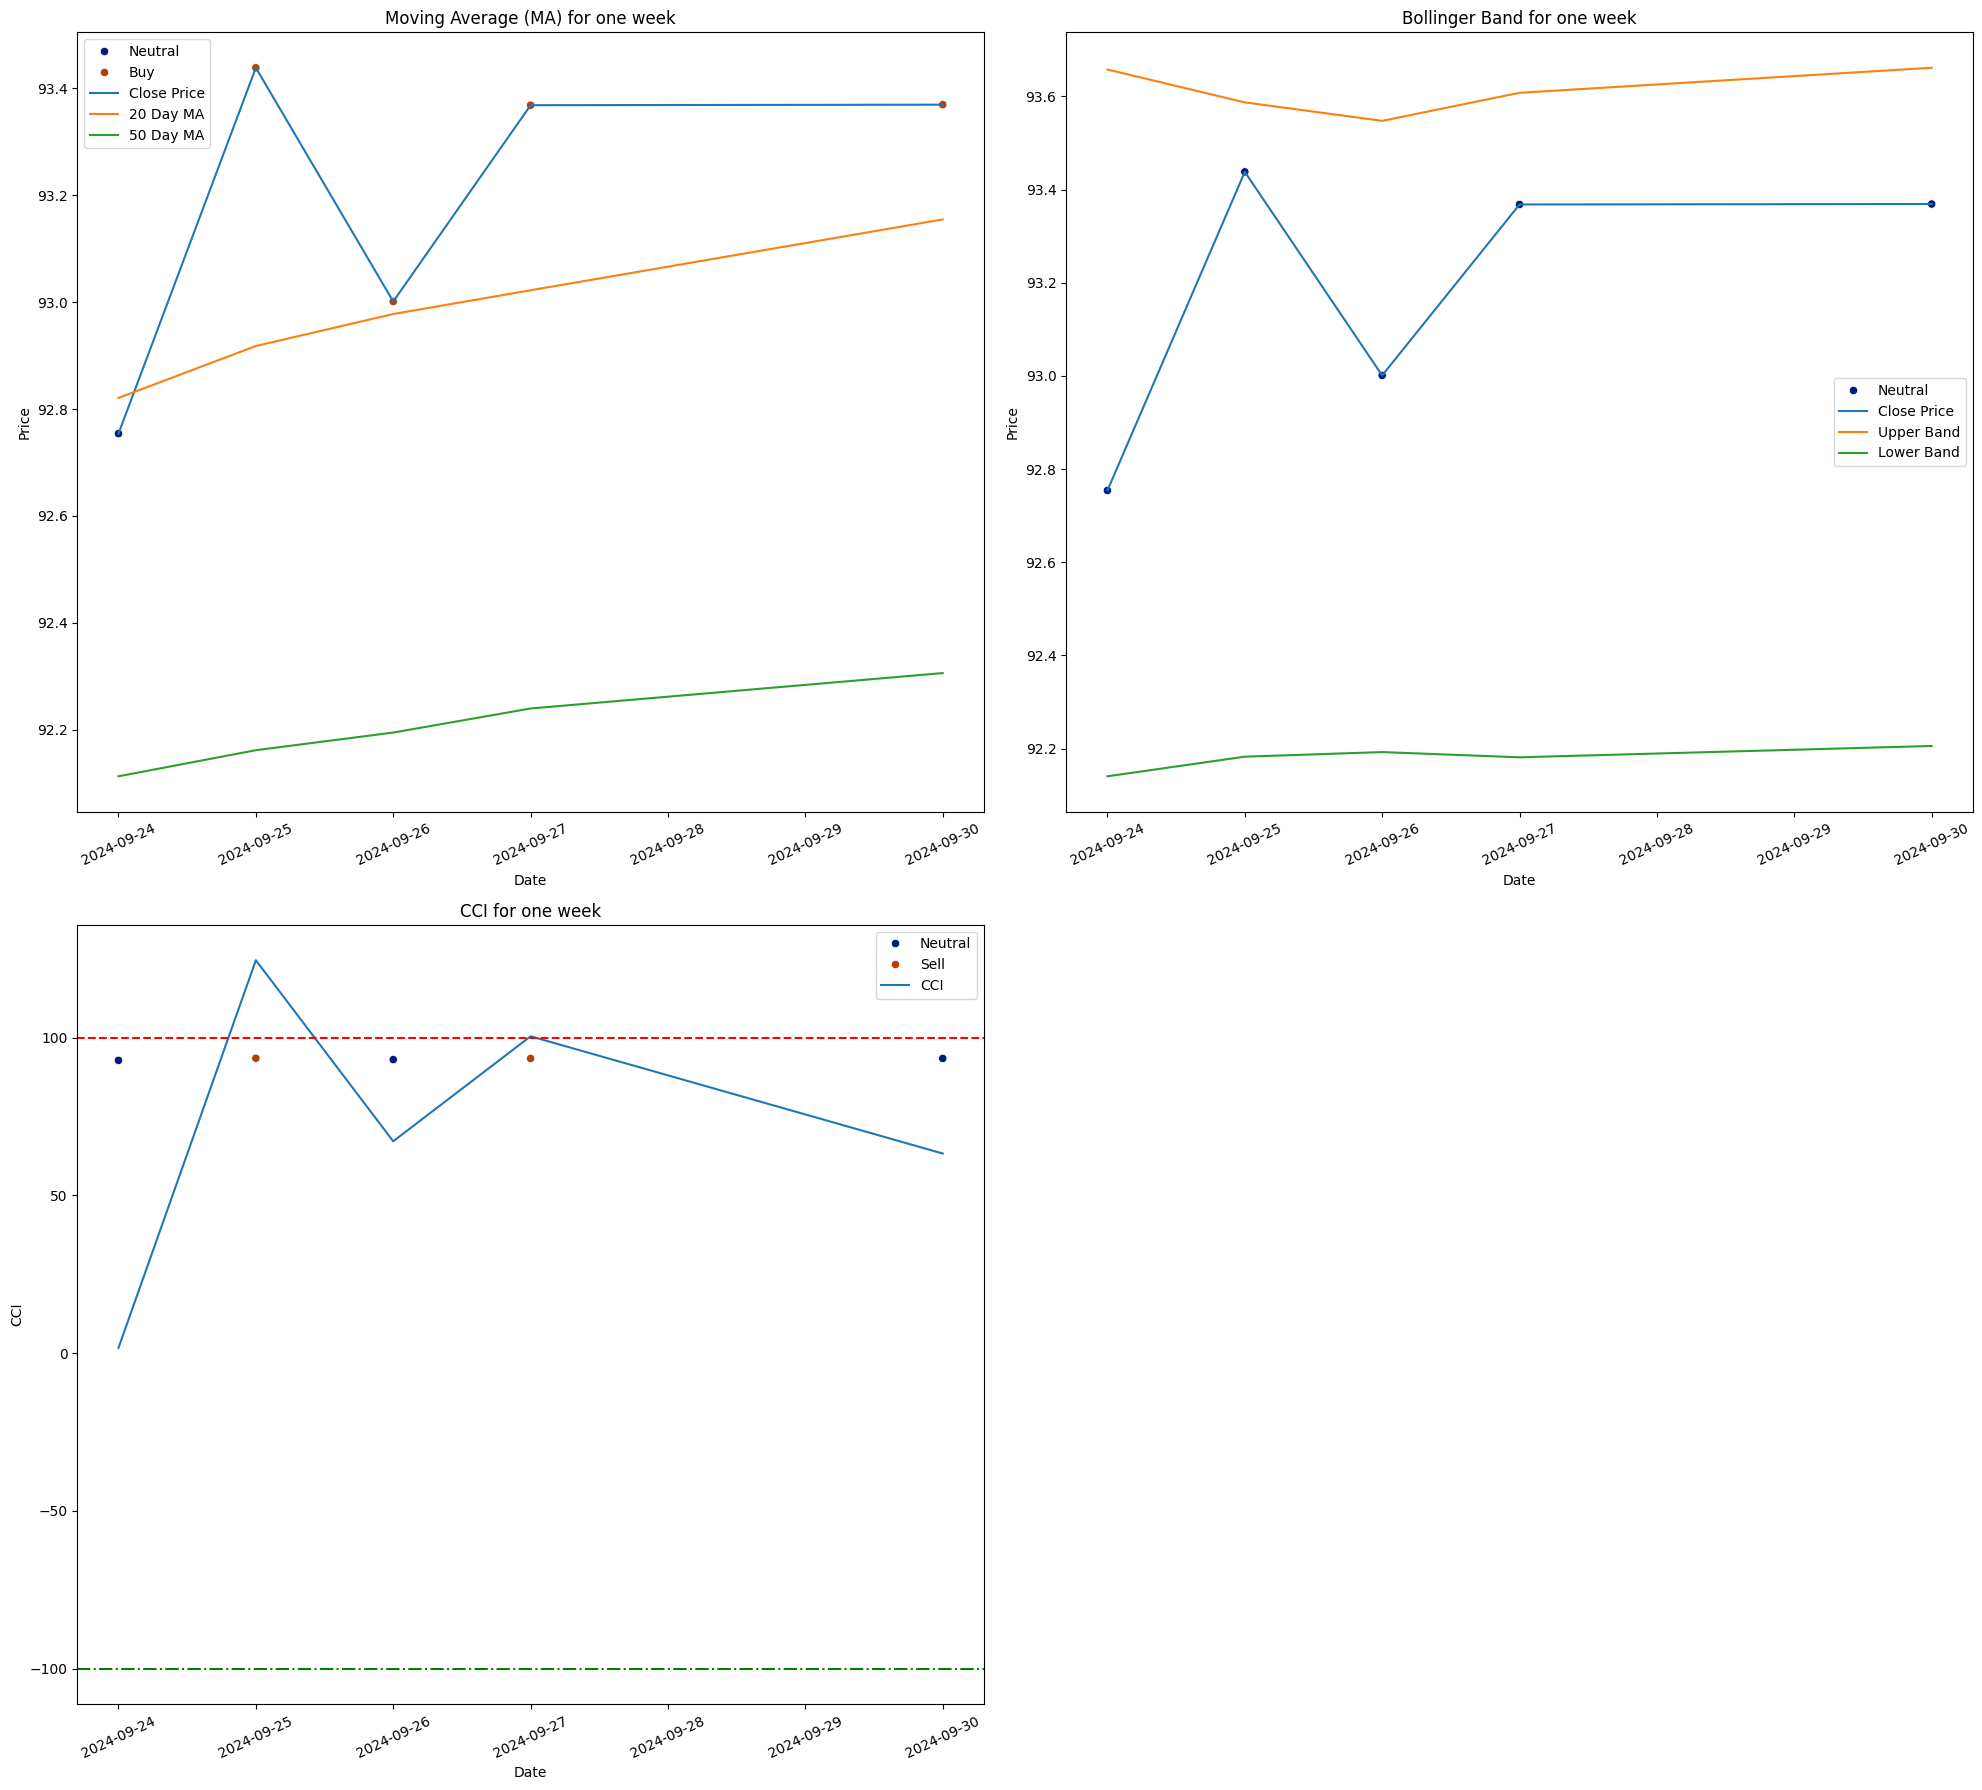

In [ ]:
plt.figure(figsize=(20, 18))

# Moving Average
plt.subplot(2, 2, 1)
sns.scatterplot(x=OWM.index, y=OWM['Close'], hue=OWM['Moving Average Decision'], palette='dark')
plt.plot(OWM.index, OWM['Close'], label='Close Price')
plt.plot(OWM.index, OWM['MA_10'], label='20 Day MA')
plt.plot(OWM.index, OWM['MA_50'], label='50 Day MA')
#plt.plot(OWM.index, OWM['Moving Average Decision'], '^', markersize=10, color='m', label='Buy Signal')
plt.title('Moving Average (MA) for one week')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 25)
plt.legend()

# Bollinger Band
plt.subplot(2, 2, 2)
sns.scatterplot(x=OWM.index, y=OWM['Close'], hue=OWM['Bollinger Band Decision'], palette='dark')
plt.plot(OWM.index, OWM['Close'], label='Close Price')
plt.plot(OWM.index, OWM['Upper'], label='Upper Band')
plt.plot(OWM.index, OWM['Lower'], label='Lower Band')
plt.title('Bollinger Band for one week')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation = 25)
plt.legend()

# CCI
plt.subplot(2, 2, 3)
sns.scatterplot(x=OWM.index, y=OWM['Close'], hue=OWM['CCI Decision'], palette='dark')
plt.plot(OWM.index, OWM['CCI'], label='CCI')
plt.axhline(y=100, color='r', linestyle='--')
plt.axhline(y=-100, color='g', linestyle='-.')
plt.xticks(rotation = 25)
plt.title('CCI for one week')
plt.xlabel('Date')
plt.ylabel('CCI')
plt.legend()

plt.tight_layout()

In [ ]:
#Displaying one day matrices after analysis
print(ODM)

Open                       92.414001
High                       93.839996
Low                        92.414001
Close                      93.369003
Volume                           0.0
Dividends                        0.0
Stock Splits                     0.0
MA_10                        93.1544
MA_50                      92.306294
MA_20                        92.9335
std_dev                     0.364013
Upper                      93.661526
Lower                      92.205475
CCI                        63.247523
Moving Average Decision          Buy
Bollinger Band Decision      Neutral
CCI Decision                 Neutral
Name: 2024-09-30 00:00:00+01:00, dtype: object


In [ ]:
#Displaying one week matrices after analysis
print(OWM)

                                Open       High        Low      Close  Volume  \
Date                                                                            
2024-09-24 00:00:00+01:00  92.775002  93.248001  92.671997  92.753998       0   
2024-09-25 00:00:00+01:00  93.490997  93.627998  93.083000  93.438004       0   
2024-09-26 00:00:00+01:00  92.995003  93.467003  92.994003  93.000999       0   
2024-09-27 00:00:00+01:00  93.371002  93.629997  93.037003  93.367996       0   
2024-09-30 00:00:00+01:00  92.414001  93.839996  92.414001  93.369003       0   

                           Dividends  Stock Splits      MA_10      MA_50  \
Date                                                                       
2024-09-24 00:00:00+01:00        0.0           0.0  92.820700  92.113302   
2024-09-25 00:00:00+01:00        0.0           0.0  92.917800  92.162082   
2024-09-26 00:00:00+01:00        0.0           0.0  92.977600  92.195082   
2024-09-27 00:00:00+01:00        0.0           0.0  